In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("spam_dataset.csv", encoding="latin1")

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1009,ham,"Dear Hero,i am leaving to qatar tonite for an ...",NaN,NaN,NaN
1107,ham,From someone not to smoke when every time I've...,NaN,NaN,NaN
4162,ham,I told that am coming on wednesday.,NaN,NaN,NaN
982,spam,Congrats! 2 mobile 3G Videophones R yours. cal...,NaN,NaN,NaN
4847,ham,S.this will increase the chance of winning.,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

<h3>1. Data Cleanning</h3>

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


We can drop last three columns as they contain very less data

In [6]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace = True )

In [7]:
df.sample()

,v1,v2
604,ham,Meet after lunch la...


In [8]:
df.rename(columns = {"v1" : "target", "v2": "text"}, inplace = True)

In [9]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [10]:
df["target"] =encoder.fit_transform(df["target"])

In [11]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df.drop_duplicates(inplace = True)

In [14]:
df.shape

(5169, 2)

In [15]:
df.duplicated().sum()

np.int64(0)

<h3>2. EDA</h3>

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

([<matplotlib.patches.Wedge at 0x23f04d47770>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

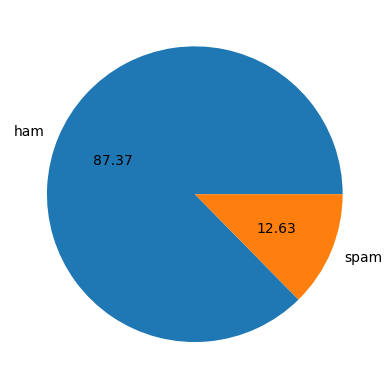

In [17]:
plt.pie(df["target"].value_counts(), labels = ["ham", "spam"], autopct = "%0.2f")

In [18]:
df["num_char"]= df["text"].apply(len)

In [19]:
df.sample()

,target,text,num_char
2675,0,I'm sick !! I'm needy !! I want you !! *pouts*...,136


In [20]:
!pip install nltk==3.8.1

In [21]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
from nltk.tokenize import word_tokenize

word_tokenize("Hello world!")

['Hello', 'world', '!']

In [23]:
df["num_words"] = df["text"].apply(lambda x:len(nltk.word_tokenize(x)))

In [24]:
df["num_sent"] = df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

In [25]:
df[["num_char", "num_words", "num_sent"]].describe()

,num_char,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
#for ham
df[df["target"]==0][["num_char", "num_words", "num_sent"]].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
#for spam
df[df["target"]==1][["num_char", "num_words", "num_sent"]].describe()

,num_char,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


Spam messages usually contain more words

<Axes: xlabel='num_char', ylabel='Count'>

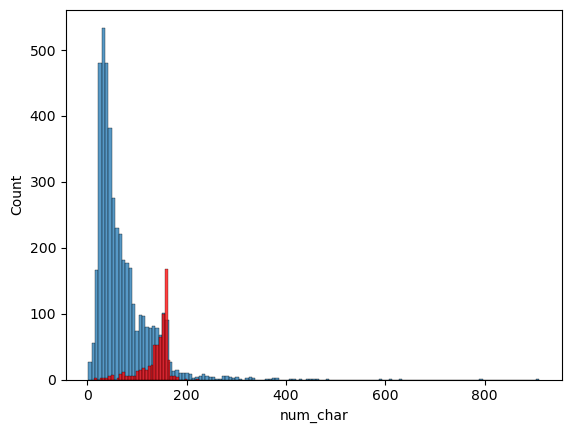

In [28]:
sns.histplot(df[df["target"]==0]["num_char"])
sns.histplot(df[df["target"]==1]["num_char"], color = "red")

We can observe with plot that ham messages contain less words and characters.

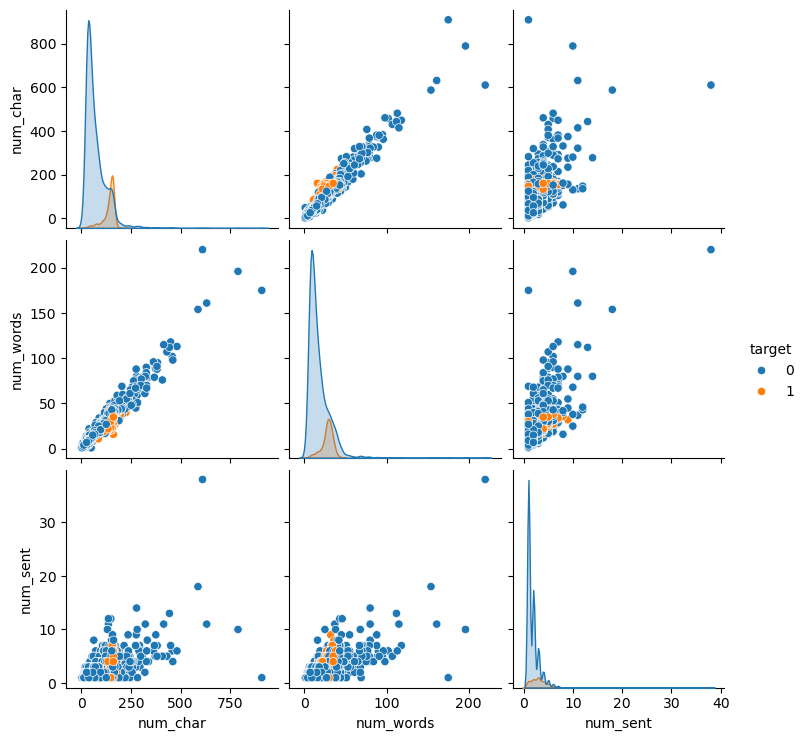

In [29]:
sns.pairplot(df, hue = "target")

<Axes: >

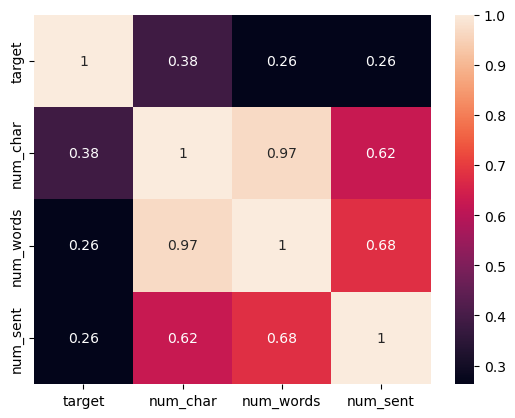

In [30]:
sns.heatmap(df[["target", "num_char", "num_words", "num_sent"]].corr(), annot = True)

<h3>3. Data Preprocessing</h3>

In [31]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [32]:
from nltk.corpus import stopwords
stopwords.words("english")

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [33]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [34]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [35]:
def processed_data(text):

    #make the text lowercase
    text = text.lower()

    #tokenisation
    text = nltk.word_tokenize(text)

    #removing special characters
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
            
    #removing stopwords and punctuations
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    #stemming
    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
        
    return " ". join(y)

In [36]:
processed_data("Hello, I am making my first project of Machine Learning.")

'hello make first project machin learn'

In [37]:
processed_data(df["text"][10])

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [38]:
df["processed_text"] = df["text"].apply(processed_data)

In [39]:
df.sample(5)

,target,text,num_char,num_words,num_sent,processed_text
3802,0,Yup song bro. No creative. Neva test quality. ...,74,17,4,yup song bro creativ neva test qualiti said ch...
2349,0,Yar else i'll thk of all sorts of funny things.,47,12,1,yar els thk sort funni thing
1435,0,Dad went out oredi...,22,5,1,dad went oredi
1541,0,Do u konw waht is rael FRIENDSHIP Im gving yuo...,212,48,1,u konw waht rael friendship im gving yuo exmpe...
5303,0,"I can. But it will tell quite long, cos i have...",71,19,2,tell quit long co finish film yet


In [40]:
 from wordcloud import WordCloud
wc = WordCloud(width = 500, height=500, min_font_size = 10, background_color = "white")

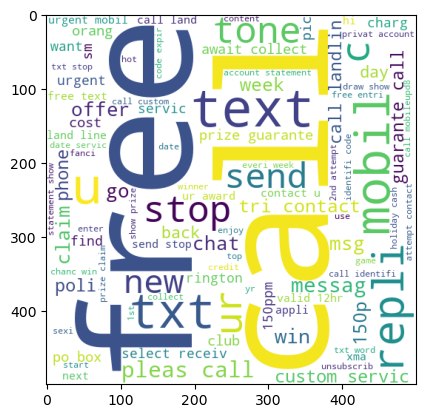

In [41]:
plt.imshow(wc.generate(df[df["target"] == 1]["processed_text"].str.cat(sep = " ")))

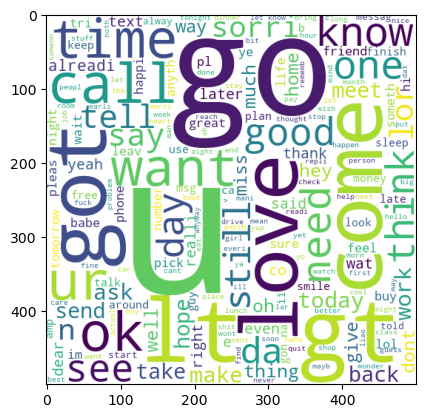

In [42]:
plt.imshow(wc.generate(df[df["target"] == 0]["processed_text"].str.cat(sep = " ")))

<h3>4. Model Building</h3>                         

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [44]:
X = cv.fit_transform(df["processed_text"]).toarray()

In [45]:
X.shape

(5169, 6708)

In [46]:
y = df["target"].values

In [47]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [50]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [51]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [52]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.8684719535783365
[[772 117]
 [ 19 126]]
0.5185185185185185


In [53]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.9738878143133463
[[872  17]
 [ 10 135]]
0.8881578947368421


In [54]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [56]:
X2 = tfidf.fit_transform(df["processed_text"]).toarray()
y2 = df["target"].values

In [57]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.2, random_state = 42)

In [58]:
gnb.fit(X2_train, y2_train)
y2_pred1 = gnb.predict(X2_test)
print(accuracy_score(y2_test, y2_pred1))
print(confusion_matrix(y2_test, y2_pred1))
print(precision_score(y2_test, y2_pred1))

0.8636363636363636
[[772 117]
 [ 24 121]]
0.5084033613445378


In [59]:
mnb.fit(X2_train, y2_train)
y2_pred2 = mnb.predict(X2_test)
print(accuracy_score(y2_test, y2_pred2))
print(confusion_matrix(y2_test, y2_pred2))
print(precision_score(y2_test, y2_pred2))

0.9613152804642167
[[888   1]
 [ 39 106]]
0.9906542056074766


In [60]:
bnb.fit(X2_train, y2_train)
y2_pred2 = bnb.predict(X2_test)
print(accuracy_score(y2_test, y2_pred2))
print(confusion_matrix(y2_test, y2_pred2))
print(precision_score(y2_test, y2_pred2))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


Since the data is imbalanced (ham messages are more than spam ones) precision will matter more than accuracy which is highest in Multinomial Naive Bayes with Tfidf.

In [61]:
!pip install xgboost

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [63]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [64]:
clfs = (svc, knc, dtc, lrc, rfc, abc, bc, etc, gbdt, xgb, mnb)

In [65]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [66]:
accuracy_scores = []
precision_scores = []

for clf in clfs:
    
    current_accuracy,current_precision = train_classifier(clf, X2_train,y2_train,X2_test,y2_test)
    
    print("For ",clf)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC(gamma=1.0, kernel='sigmoid')
Accuracy -  0.971953578336557
Precision -  0.9393939393939394
For  KNeighborsClassifier()
Accuracy -  0.8965183752417795
Precision -  1.0
For  DecisionTreeClassifier(max_depth=5)
Accuracy -  0.9352030947775629
Precision -  0.8145161290322581
For  LogisticRegression(penalty='l1', solver='liblinear')
Accuracy -  0.9439071566731141
Precision -  0.865546218487395
For  RandomForestClassifier(n_estimators=50, random_state=2)
Accuracy -  0.9700193423597679
Precision -  0.9913793103448276
For  AdaBoostClassifier(random_state=2)
Accuracy -  0.9148936170212766
Precision -  0.7878787878787878
For  BaggingClassifier(n_estimators=50, random_state=2)
Accuracy -  0.9613152804642167
Precision -  0.8776978417266187
For  ExtraTreesClassifier(n_estimators=50, random_state=2)
Accuracy -  0.9738878143133463
Precision -  0.9916666666666667
For  GradientBoostingClassifier(n_estimators=50, random_state=2)
Accuracy -  0.9506769825918762
Precision -  0.9519230769230769
For 

We get the best precision for Multinomial Naive Bayes, K nearest neighbour and random forest. Among these Naive Bayes gives the best accuracy, therefore we choose it as our model.

In [68]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))